2025-26 Project
You have to work on the Trending YouTube dataset.

Notes
It is mandatory to use GitHub for developing the project.
The project must be a jupyter notebook.
There is no restriction on the libraries that can be used, nor on the Python version.
All questions on the project must be asked in the Discussion forum on the course website.
At most 3 students can be in each group. You must create the groups by yourself. You can use the Discussion forum to create the groups.
You do not have to send me the project before the discussion.
You do not have to prepare any slides for the discussion.
You can use AI tools, but you have to describe in the notebook how you have used such tools and you have to show that you have fully understood everything that you have in your project.
1. Create a single dataframe with the concatenation of all input csv files, adding a column called country
2. Extract all videos that have no tag.
3. For each channel, determine the total number of views
4. Save all rows with disabled comments and disabled ratings, or that have video_error_or_removed in a new dataframe called excluded, and remove those rows from the original dataframe.
5. Add a like_ratio column storing the ratio between the number of likes and of dislikes
6. Cluster the publish time into 10-minute intervals (e.g. from 02:20 to 02:30)
7. For each interval, determine the number of videos, average number of likes and of dislikes.
8. For each tag, determine the number of videos
Notice that tags contains a string with several tags.

9. Find the tags with the largest number of videos
10. For each (tag, country) pair, compute average ratio likes/dislikes
11. For each (trending_date, country) pair, the video with the largest number of views
12. Divide trending_date into three columns: year, month, day
13. For each (month, country) pair, the video with the largest number of views
14. Read all json files with the video categories
15. For each country, determine how many videos have a category that is not assignable.

In [1]:
# All necessary imports
import pandas as pd
import numpy as np
import glob
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [2]:
path = './data/csv/' 
csv_files = glob.glob(os.path.join(path, "*.csv"))

In [3]:
# ==========================================
# 1. Create a single dataframe with concatenation of all input csv files, adding a column called country
# ==========================================
df_list = []

for filename in csv_files:
    # Read each CSV file
    # temp_df = pd.read_csv(filename, encoding='latin-1')  # tried utf-8 but got errors. latin-1 works better for this dataset.
    
    # Using utf-8 with replacement for errors to handle non-latin characters correctly (e.g. CJK)
    temp_df = pd.read_csv(filename, encoding='utf-8', encoding_errors='replace', on_bad_lines='skip')

    # Extract country code from filename (assuming format like 'USvideos.csv')
    # logic: take the basename, remove extension, and take first 2 chars
    base = os.path.basename(filename)
    country_code = base[0:2].upper() 
    
    temp_df['country'] = country_code
    df_list.append(temp_df)

print(f"Found {len(df_list)} CSV files.")
# Concatenate all dataframes
df = pd.concat(df_list, axis=0, ignore_index=True)

print(f"Dataframe created with shape {df.shape}")
print(df['country'].value_counts())
print(df.head(3))

Found 10 CSV files.
Dataframe created with shape (375942, 17)
country
US    40949
CA    40881
DE    40840
RU    40739
FR    40724
MX    40451
GB    38916
IN    37352
KR    34567
JP    20523
Name: count, dtype: int64
      video_id trending_date  \
0  n1WpP7iowLc      17.14.11   
1  0dBIkQ4Mz1M      17.14.11   
2  5qpjK5DgCt4      17.14.11   

                                               title channel_title  \
0         Eminem - Walk On Water (Audio) ft. Beyoncé    EminemVEVO   
1                      PLUSH - Bad Unboxing Fan Mail     iDubbbzTV   
2  Racist Superman | Rudy Mancuso, King Bach & Le...  Rudy Mancuso   

   category_id              publish_time  \
0           10  2017-11-10T17:00:03.000Z   
1           23  2017-11-13T17:00:00.000Z   
2           23  2017-11-12T19:05:24.000Z   

                                                tags     views   likes  \
0  Eminem|"Walk"|"On"|"Water"|"Aftermath/Shady/In...  17158579  787425   
1  plush|"bad unboxing"|"unboxing"|"fan mail"|"id

In [4]:
# ==========================================
# 2. Extract all videos that have no tag.
# ==========================================

# In this dataset, tags are represented as "[none]" string when there are no tags. 
# (Manually checked CAvidoes.csv and found 2385 values with "[none]" tags.)
# (Also DEvideos.csv has 3031 such values.)
videos_no_tags = df[(df['tags'].isna()) | (df['tags'] == '[none]')]
print(f"Step 2: Found {len(videos_no_tags)} videos with no tags.")
print("Percentage of videos with no tags: {:.2f}%".format((len(videos_no_tags) / len(df)) * 100))
print("------------------------------------------")
print("Videos with no tags by country:")
print(videos_no_tags['country'].value_counts())
print("------------------------------------------")
print("Sample videos with no tags:")
print(videos_no_tags[['video_id', 'title', 'country']].head(5))

Step 2: Found 37698 videos with no tags.
Percentage of videos with no tags: 10.03%
------------------------------------------
Videos with no tags by country:
country
MX    7685
KR    7183
FR    5304
RU    3984
JP    3200
DE    3031
CA    2385
GB    2010
US    1535
IN    1381
Name: count, dtype: int64
------------------------------------------
Sample videos with no tags:
       video_id                                              title country
41  JwboxqDylgg  Canada Soccer's Women's National Team v USA In...      CA
58  9B-q8h31Bpk  John Oliver Tackles Louis C.K. And Donald Trum...      CA
78  1UE5Dq1rvUA            Taylor Swift Perform Ready For It - SNL      CA
86  pmJQ4KwliX4  LATEST Q POSTS: ROTHSCHILDS, HOUSE OF SAUD, lL...      CA
98  lHcXhBojpeQ                   三屆TVB視帝，拋棄10年青梅竹馬髮妻，為娶小三還不惜與母絕交！      CA


In [5]:
# ==========================================
# 3. For each channel, determine the total number of views
# ==========================================

channel_views = df.groupby('channel_title')['views'].sum().sort_values(ascending=False)
print("Total views per channel (top 5):\n", channel_views.head())
print("Toal unique channels:", channel_views.shape[0])

Total views per channel (top 5):
 channel_title
ChildishGambinoVEVO     11016766510
Marvel Entertainment    10430605449
NickyJamTV               9479859505
Ozuna                    8623329509
ibighit                  8205572221
Name: views, dtype: int64
Toal unique channels: 37824


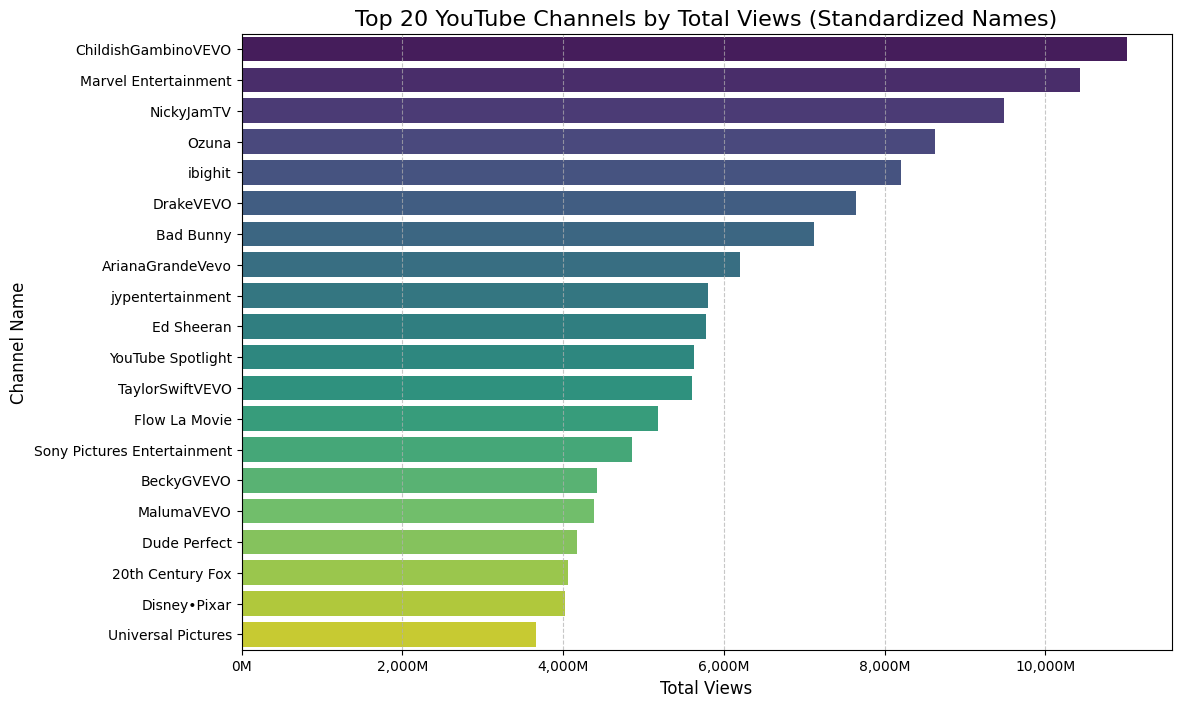

In [6]:
# Prepare the data
top_n = 20
top_channels = channel_views.head(top_n).copy()
# Fix for the Seaborn warning about non-ASCII characters
# top_channels.index = top_channels.index.astype(str).str.encode('ascii', 'ignore').str.decode('ascii')
# ---------------

# Create the plot
plt.figure(figsize=(12, 8))

# Fix for the Seaborn warning is included here too
sns.barplot(
    x=top_channels.values, 
    y=top_channels.index, 
    hue=top_channels.index, 
    legend=False, 
    palette='viridis'
)

plt.title(f'Top {top_n} YouTube Channels by Total Views (Standardized Names)', fontsize=16)
plt.xlabel('Total Views', fontsize=12)
plt.ylabel('Channel Name', fontsize=12)

# Format X-axis
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x/1e6) + 'M'))
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

In [7]:
# ==========================================
# 4. Save all rows with disabled comments and disabled ratings, 
# or that have video_error_or_removed in a new dataframe called excluded, 
# and remove those rows from the original dataframe.
# ==========================================

# Step 4: identifying the condition
condition = (
    (df['comments_disabled'] == True) & 
    (df['ratings_disabled'] == True)
) | (df['video_error_or_removed'] == True)

# Create 'excluded' dataframe
excluded = df[condition].copy()

# Remove specific rows from original dataframe (keep those that are NOT condition)
df = df[~condition].copy()

print(f"{len(excluded)} rows moved to 'excluded'. Remaining rows: {len(df)}")

2620 rows moved to 'excluded'. Remaining rows: 373322


In [8]:
# ==========================================
# 5. Add a like_ratio column storing the ratio between 
# the number of likes and of dislikes
# ==========================================

# Handle division by zero if dislikes is 0. We can fill inf with 0 or NaN depending on preference.
# Here we replace 0 dislikes with 1 to avoid error, or just let numpy handle infs.
# A safer approach for analysis:
df['like_ratio'] = df['likes'] / df['dislikes'].replace(0, 1)
print("'like_ratio' column added.")

'like_ratio' column added.


In [9]:
df.head(2)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country,like_ratio
0,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787425,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. Beyoncé i...,CA,18.135076
1,0dBIkQ4Mz1M,17.14.11,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,2017-11-13T17:00:00.000Z,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",1014651,127794,1688,13030,https://i.ytimg.com/vi/0dBIkQ4Mz1M/default.jpg,False,False,False,STill got a lot of packages. Probably will las...,CA,75.707346


In [10]:
# ==========================================
# 6. Cluster the publish time into 10-minute intervals (e.g. from 02:20 to 02:30)
# ==========================================

# Convert publish_time to datetime objects
df['publish_time'] = pd.to_datetime(df['publish_time'])

# Floor the time to 10-minute frequency
df['publish_interval'] = df['publish_time'].dt.floor('10min')

# If you need just the time component (independent of date):
# df['publish_interval_time'] = df['publish_time'].dt.floor('10T').dt.time
print("Step 6: Publish time clustered into 10-minute intervals.")
df[['publish_time', 'publish_interval']].head(10)

Step 6: Publish time clustered into 10-minute intervals.


,publish_time,publish_interval
0,2017-11-10 17:00:03+00:00,2017-11-10 17:00:00+00:00
1,2017-11-13 17:00:00+00:00,2017-11-13 17:00:00+00:00
2,2017-11-12 19:05:24+00:00,2017-11-12 19:00:00+00:00
3,2017-11-12 18:01:41+00:00,2017-11-12 18:00:00+00:00
4,2017-11-09 11:04:14+00:00,2017-11-09 11:00:00+00:00
5,2017-11-13 07:37:51+00:00,2017-11-13 07:30:00+00:00
6,2017-11-12 23:52:13+00:00,2017-11-12 23:50:00+00:00
7,2017-11-13 17:13:01+00:00,2017-11-13 17:10:00+00:00
8,2017-11-12 20:19:24+00:00,2017-11-12 20:10:00+00:00
9,2017-11-10 14:10:46+00:00,2017-11-10 14:10:00+00:00


In [11]:
# ==========================================
# 7. For each interval, determine the number of videos, 
# average number of likes and of dislikes.
# ==========================================

interval_stats = df.groupby('publish_interval').agg({
    'video_id': 'count',   # Number of videos
    'likes': 'mean',       # Average likes
    'dislikes': 'mean'     # Average dislikes
}).rename(columns={'video_id': 'num_videos'})

print("Step 7: Interval stats (first 5 rows):\n", interval_stats.head())

Step 7: Interval stats (first 5 rows):
                            num_videos       likes  dislikes
publish_interval                                           
2006-07-23 08:20:00+00:00           1  459.000000  152.0000
2007-03-05 16:20:00+00:00           9  336.666667    2.0000
2007-06-25 06:50:00+00:00          12  579.833333   11.5000
2007-12-03 20:50:00+00:00          16  187.937500   15.6875
2008-01-07 21:20:00+00:00          10   99.900000    2.0000


In [12]:
# ==========================================
# 8. For each tag, determine the number of videos
# Notice that tags contains a string with several tags.
# ==========================================

# We need to split the tags string. Usually separated by '|' in this dataset.
# We drop rows with no tags first to avoid errors.
tags_series = df['tags'].replace('[none]', np.nan).dropna()

# Split tags by '|' and stack them into a single series
all_tags = tags_series.str.split('|', expand=True).stack()

# Remove empty tags that might result from splitting or bad data
all_tags = all_tags[all_tags.str.strip() != '']

# Count occurrences
tag_counts = all_tags.value_counts()
print("Counted videos per tag.")
tag_counts.head(10)



Counted videos per tag.


"funny"         14933
"comedy"        11962
"2018"          11029
"news"           5955
"music"          5590
"2017"           5500
"video"          5391
"humor"          5036
"television"     4160
"show"           4131
Name: count, dtype: int64

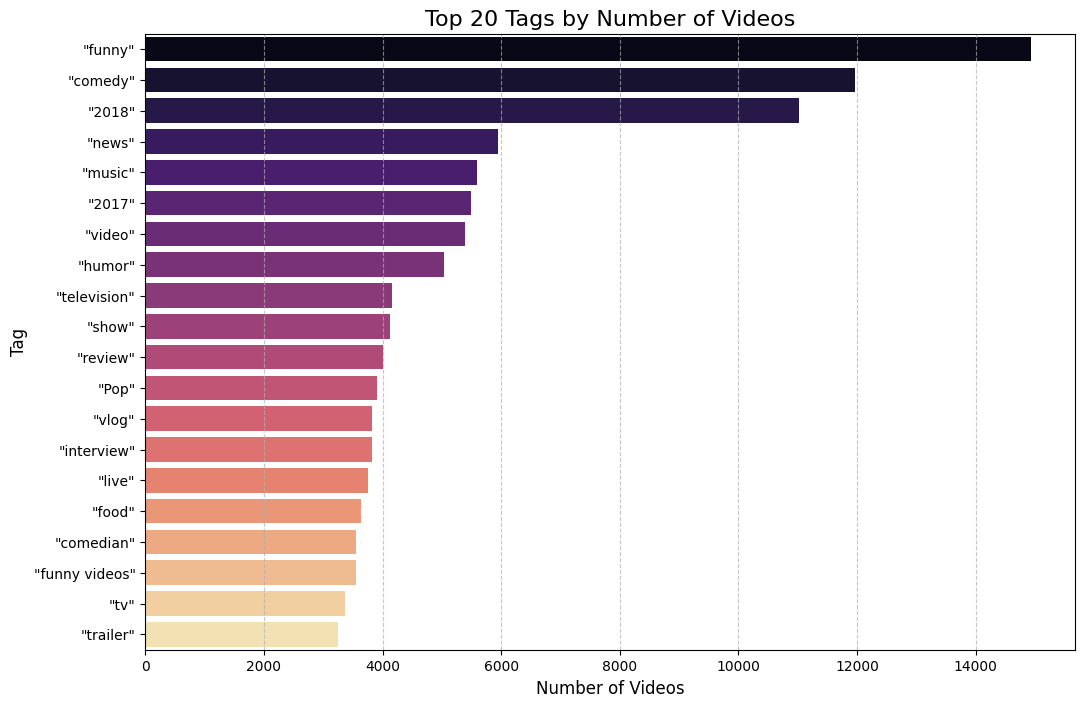

In [13]:

# Create the plot
plt.figure(figsize=(12, 8))
sns.barplot(x=tag_counts.head(20).values, y=tag_counts.head(20).index, hue=tag_counts.head(20).index, legend=False, palette='magma')
plt.title('Top 20 Tags by Number of Videos', fontsize=16)
plt.xlabel('Number of Videos', fontsize=12) 
plt.ylabel('Tag', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [14]:
# ==========================================
# 9. Find the tags with the largest number of videos
# ==========================================

print("Top 5 tags with largest number of videos:\n",tag_counts.head(5))

Top 5 tags with largest number of videos:
 "funny"     14933
"comedy"    11962
"2018"      11029
"news"       5955
"music"      5590
Name: count, dtype: int64


In [15]:
# ==========================================
# 10. For each (tag, country) pair, compute average ratio likes/dislikes
# ==========================================

# Since extracting every tag duplicates rows significantly, we create a temporary exploded dataframe
# example: "Sing zu Ende! | Gesangseinlagen vom Feinsten | inscope21"
df_tags = df[['tags', 'country', 'like_ratio']].copy()
# Remove invalid tags
df_tags = df_tags[df_tags['tags'] != '[none]'].dropna()

# Split tags and explode to create one row per tag
df_tags['tag'] = df_tags['tags'].str.split('|')
df_exploded = df_tags.explode('tag')

# Clean up tags (strip quotes if necessary)
df_exploded['tag'] = df_exploded['tag'].str.strip('"')

# Remove empty tags
df_exploded = df_exploded[df_exploded['tag'].str.strip() != '']

# Group by tag and country
tag_country_ratio = df_exploded.groupby(['tag', 'country'])['like_ratio'].mean()

print("Step 10: Computed average like_ratio per (tag, country).")
tag_country_ratio.head(10)

Step 10: Computed average like_ratio per (tag, country).


tag                      country
#Freeticket              IN          2.665679
#GST                     IN          2.416896
#Jaisimha                IN          2.665679
#JanaSenaParty           IN         17.621907
#MahaaNews               IN          8.511947
#PawanKalyan #AlluArjun  IN          9.983453
#PrimeTimeWithMurthy     IN          6.263998
#RamGopalVarma           IN          2.416896
#SUSANNE                 DE         78.841463
#VMA 20                  FR          9.615385
Name: like_ratio, dtype: float64

we have a possible problem of language. this code separate the tags but cannot merge cute from japanese with cute from english.

In [16]:
# Check the results for Japan (JP) to ensure foreign characters are there
print("Top 5 Tags in Japan:")
print(tag_country_ratio.loc[(slice(None), 'JP')].head(5))

# You can also search for a specific tag if you know one, or just view the tail
print("\nSample of calculated ratios:")
print(tag_country_ratio.tail())

Top 5 Tags in Japan:
tag
1 Billion Bounty Man                  30.612903
100% Will Get Satisfied                7.731893
2018                                  10.435623
3rd T20                               10.435623
Hoàng Anh Gia Lai vs B. Bình Dương     9.000000
Name: like_ratio, dtype: float64

Sample of calculated ratios:
tag                                              country
😥                                                DE         26.384615
😭 #résistancelamaindesqueezie ❤️                 FR         10.219048
😭قفز عسكري الوحيد من الطائرة العسكرية الجزائرية  FR          6.223873
🚀 smartpixel.com.ua                              RU          0.714286
🤝 ZARBEX zahlt Schutzgeld!!!                     DE         13.989691
Name: like_ratio, dtype: float64


In [17]:
# ==========================================
# 11. For each (trending_date, country) pair, the video with the largest number of views
# ==========================================

# Get index of max views
idx_max_views = df.groupby(['trending_date', 'country'])['views'].idxmax()

# Select rows
top_videos_trending = df.loc[idx_max_views]
print("Step 11: Identified top viewed videos per trending_date and country.")
top_videos_trending.head(3)

Step 11: Identified top viewed videos per trending_date and country.


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country,like_ratio,publish_interval
3398,6ZfuNTqbHE8,17.01.12,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,24,2017-11-29 13:26:24+00:00,"marvel|""comics""|""comic books""|""nerdy""|""geeky""|...",56367282,2157741,34078,303178,https://i.ytimg.com/vi/6ZfuNTqbHE8/default.jpg,False,False,False,There was an idea… Avengers: Infinity War. In ...,CA,63.317712,2017-11-29 13:20:00+00:00
221284,6ZfuNTqbHE8,17.01.12,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,24,2017-11-29 13:26:24+00:00,"marvel|""comics""|""comic books""|""nerdy""|""geeky""|...",56367282,2157737,34077,303178,https://i.ytimg.com/vi/6ZfuNTqbHE8/default.jpg,False,False,False,There was an idea… Avengers: Infinity War. In ...,DE,63.319453,2017-11-29 13:20:00+00:00
99502,3VbHg5fqBYw,17.01.12,Avengers: Infinity War Trailer Tease,Marvel Entertainment,24,2017-11-28 17:09:22+00:00,"marvel""|""comics""|""comic books""|""nerdy""|""geeky""...",7281189,180808,19955,21244,https://i.ytimg.com/vi/3VbHg5fqBYw/default.jpg,False,False,False,Thank you to the best fans in the universe! Ma...,FR,9.060787,2017-11-28 17:00:00+00:00


In [18]:
# ==========================================
# 12. Divide trending_date into three columns: year, month, day
# ==========================================

# The format of trending_date in this dataset is "2017-11-13T17:08:49.000Z"  (manually checked a few entries)
df['trending_dt'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')

df['year'] = df['trending_dt'].dt.year
df['month'] = df['trending_dt'].dt.month
df['day'] = df['trending_dt'].dt.day

print("year, month, day columns added.")
top_videos_trending.head(3)

year, month, day columns added.


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country,like_ratio,publish_interval
3398,6ZfuNTqbHE8,17.01.12,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,24,2017-11-29 13:26:24+00:00,"marvel|""comics""|""comic books""|""nerdy""|""geeky""|...",56367282,2157741,34078,303178,https://i.ytimg.com/vi/6ZfuNTqbHE8/default.jpg,False,False,False,There was an idea… Avengers: Infinity War. In ...,CA,63.317712,2017-11-29 13:20:00+00:00
221284,6ZfuNTqbHE8,17.01.12,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,24,2017-11-29 13:26:24+00:00,"marvel|""comics""|""comic books""|""nerdy""|""geeky""|...",56367282,2157737,34077,303178,https://i.ytimg.com/vi/6ZfuNTqbHE8/default.jpg,False,False,False,There was an idea… Avengers: Infinity War. In ...,DE,63.319453,2017-11-29 13:20:00+00:00
99502,3VbHg5fqBYw,17.01.12,Avengers: Infinity War Trailer Tease,Marvel Entertainment,24,2017-11-28 17:09:22+00:00,"marvel""|""comics""|""comic books""|""nerdy""|""geeky""...",7281189,180808,19955,21244,https://i.ytimg.com/vi/3VbHg5fqBYw/default.jpg,False,False,False,Thank you to the best fans in the universe! Ma...,FR,9.060787,2017-11-28 17:00:00+00:00


In [19]:
df.head(3)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,ratings_disabled,video_error_or_removed,description,country,like_ratio,publish_interval,trending_dt,year,month,day
0,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10,2017-11-10 17:00:03+00:00,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787425,43420,...,False,False,Eminem's new track Walk on Water ft. Beyoncé i...,CA,18.135076,2017-11-10 17:00:00+00:00,2017-11-14,2017,11,14
1,0dBIkQ4Mz1M,17.14.11,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,2017-11-13 17:00:00+00:00,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",1014651,127794,1688,...,False,False,STill got a lot of packages. Probably will las...,CA,75.707346,2017-11-13 17:00:00+00:00,2017-11-14,2017,11,14
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146035,5339,...,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,CA,27.352500,2017-11-12 19:00:00+00:00,2017-11-14,2017,11,14


In [20]:

# ==========================================
# 13. For each (month, country) pair, the video with the largest number of views
# ==========================================

idx_max_views_month = df.groupby(['month', 'country'])['views'].idxmax()
top_videos_month = df.loc[idx_max_views_month]
print("Step 13: Identified top viewed videos per month and country.")
top_videos_month.head(3)

Step 13: Identified top viewed videos per month and country.


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,ratings_disabled,video_error_or_removed,description,country,like_ratio,publish_interval,trending_dt,year,month,day
11214,LsoLEjrDogU,18.09.01,Bruno Mars - Finesse (Remix) [Feat. Cardi B] [...,Bruno Mars,10,2018-01-04 04:49:43+00:00,"Bruno Mars|""Finesse""|""Cardi B""|""Finesse Remix""...",43067983,1717177,61567,...,False,False,Finesse (Remix) Feat. Cardi B Available Now: h...,CA,27.891192,2018-01-04 04:40:00+00:00,2018-01-09,2018,1,9
228934,LsoLEjrDogU,18.08.01,Bruno Mars - Finesse (Remix) [Feat. Cardi B] [...,Bruno Mars,10,2018-01-04 04:49:43+00:00,"Bruno Mars|""Finesse""|""Cardi B""|""Finesse Remix""...",37728802,1629946,56305,...,False,False,Finesse (Remix) Feat. Cardi B Available Now: h...,DE,28.948513,2018-01-04 04:40:00+00:00,2018-01-08,2018,1,8
107103,LsoLEjrDogU,18.08.01,Bruno Mars - Finesse (Remix) [Feat. Cardi B] [...,Bruno Mars,10,2018-01-04 04:49:43+00:00,"Bruno Mars""|""Finesse""|""Cardi B""|""Finesse Remix...",37728802,1629948,56305,...,False,False,Finesse (Remix) Feat. Cardi B Available Now: h...,FR,28.948548,2018-01-04 04:40:00+00:00,2018-01-08,2018,1,8


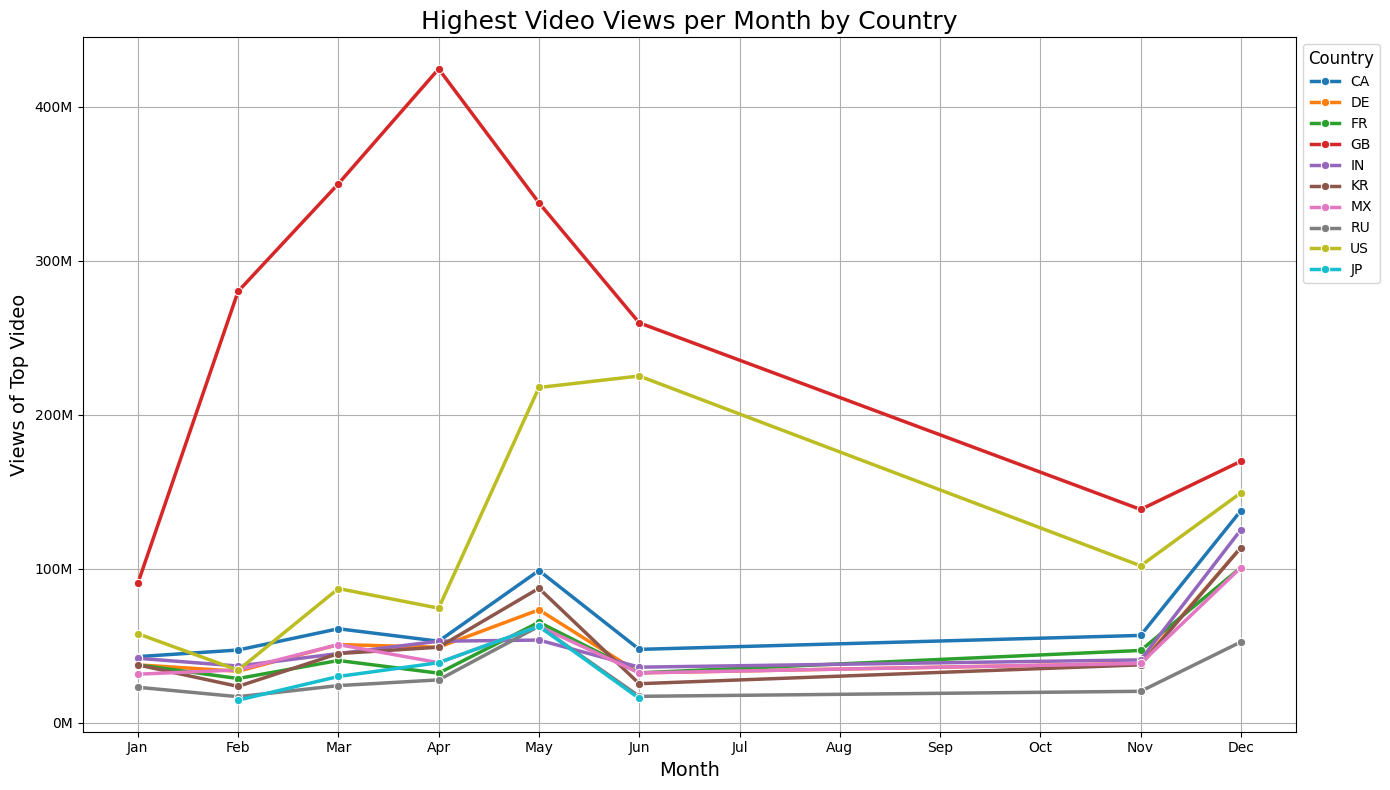

In [21]:
# plot top videos per month per country - for myself
plot_data = top_videos_month.sort_values('month').copy()
plt.figure(figsize=(14, 8))

# Create the Line Plot
# Hue='country' creates a separate colored line for each country
sns.lineplot(
    data=plot_data,
    x='month',
    y='views',
    hue='country',
    marker='o',       # Adds dots at data points
    linewidth=2.5,
    palette='tab10'   # Distinct colors
)

# Titles and Labels
plt.title('Highest Video Views per Month by Country', fontsize=18)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Views of Top Video', fontsize=14)

# Format X-Axis to show Month Names instead of numbers
# Setting ticks for 1-12 and map them to months
ax = plt.gca()
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Format Y-Axis to Millions
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x/1e6) + 'M'))

plt.legend(title='Country', title_fontsize='12', fontsize='10', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()

plt.tight_layout()
plt.show()

In [22]:
top_videos_month.head(3)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,ratings_disabled,video_error_or_removed,description,country,like_ratio,publish_interval,trending_dt,year,month,day
11214,LsoLEjrDogU,18.09.01,Bruno Mars - Finesse (Remix) [Feat. Cardi B] [...,Bruno Mars,10,2018-01-04 04:49:43+00:00,"Bruno Mars|""Finesse""|""Cardi B""|""Finesse Remix""...",43067983,1717177,61567,...,False,False,Finesse (Remix) Feat. Cardi B Available Now: h...,CA,27.891192,2018-01-04 04:40:00+00:00,2018-01-09,2018,1,9
228934,LsoLEjrDogU,18.08.01,Bruno Mars - Finesse (Remix) [Feat. Cardi B] [...,Bruno Mars,10,2018-01-04 04:49:43+00:00,"Bruno Mars|""Finesse""|""Cardi B""|""Finesse Remix""...",37728802,1629946,56305,...,False,False,Finesse (Remix) Feat. Cardi B Available Now: h...,DE,28.948513,2018-01-04 04:40:00+00:00,2018-01-08,2018,1,8
107103,LsoLEjrDogU,18.08.01,Bruno Mars - Finesse (Remix) [Feat. Cardi B] [...,Bruno Mars,10,2018-01-04 04:49:43+00:00,"Bruno Mars""|""Finesse""|""Cardi B""|""Finesse Remix...",37728802,1629948,56305,...,False,False,Finesse (Remix) Feat. Cardi B Available Now: h...,FR,28.948548,2018-01-04 04:40:00+00:00,2018-01-08,2018,1,8


In [23]:
# ==========================================
# 14. Read all json files with the video categories
# ==========================================

# We need a dictionary that maps: Country -> { Category_ID -> Is_Assignable (True/False) }
assignable_map = {}
path_json = './data/json/'
json_files = glob.glob(os.path.join(path_json, "*.json"))

for j_file in json_files:
    # Extract country code (e.g., 'CA_category_id.json' -> 'CA') like with csv files
    filename = os.path.basename(j_file)
    print(f"Processing JSON file: {filename}")
    country_code = filename.split('_')[0]
    
    with open(j_file, 'r') as f:
        data = json.load(f)
        
    # We cast the ID to int because the CSV usually contains integers, 
    # while the JSON contains strings like "10".

    """
    {
   "kind": "youtube#videoCategory",
   "etag": "\"ld9biNPKjAjgjV7EZ4EKeEGrhao/UZ1oLIIz2dxIhO45ZTFR3a3NyTA\"",
   "id": "2",
   "snippet": {
    "channelId": "UCBR8-60-B28hp2BmDPdntcQ",
    "title": "Autos & Vehicles",
    "assignable": true
   }
  },
    """
    country_cats = {}
    for item in data['items']:
        cat_id = int(item['id'])
        # the boolean is located at item['snippet']['assignable']
        is_assignable = item['snippet']['assignable']
        country_cats[cat_id] = is_assignable
        
    assignable_map[country_code] = country_cats

print(f"Step 14: Successfully read category files for {len(assignable_map)} countries.")

Processing JSON file: IN_category_id.json
Processing JSON file: MX_category_id.json
Processing JSON file: US_category_id.json
Processing JSON file: KR_category_id.json
Processing JSON file: GB_category_id.json
Processing JSON file: CA_category_id.json
Processing JSON file: FR_category_id.json
Processing JSON file: DE_category_id.json
Processing JSON file: JP_category_id.json
Processing JSON file: RU_category_id.json
Step 14: Successfully read category files for 10 countries.


In [24]:
df['country'].unique()

array(['CA', 'KR', 'JP', 'FR', 'MX', 'RU', 'DE', 'GB', 'US', 'IN'],
      dtype=object)

In [25]:
# ==========================================
# 15. For each country, determine how many videos have a category that is not assignable.
# ==========================================

unassignable_counts = {}

# Iterate through each country present in the main dataframe
for country in df['country'].unique():
    current_map = assignable_map.get(country, {})
    
    # Filtering the main dataframe for this country
    country_df = df[df['country'] == country]
    
    # Check assignability
    # We look up the category_id in our map.
    # If the id is NOT in the map, it's unassignable (returns False via default).
    # If the id is in the map, we return its explicit True/False value.
    
    def check_assignable(cat_id):
        # Returns True if exists AND is assignable
        # Returns False if 'assignable': false OR key doesn't exist
        return current_map.get(cat_id, False)
    
    # Apply the check
    valid_mask = country_df['category_id'].apply(check_assignable)
    
    # The prompt asks for "not assignable", so we sum the False values (~ <- bit wise not)
    count_not_assignable = (~valid_mask).sum()
    
    unassignable_counts[country] = count_not_assignable

print("Step 15: Count of videos with 'not assignable' categories per country:")
print(unassignable_counts)

Step 15: Count of videos with 'not assignable' categories per country:
{'CA': np.int64(204), 'KR': np.int64(453), 'JP': np.int64(18), 'FR': np.int64(223), 'MX': np.int64(254), 'RU': np.int64(1733), 'DE': np.int64(352), 'GB': np.int64(110), 'US': np.int64(57), 'IN': np.int64(295)}


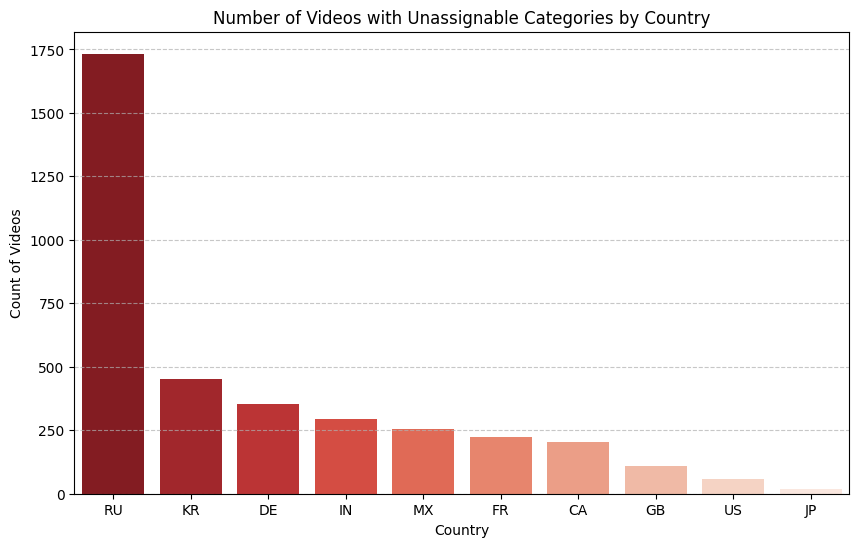

In [26]:
plt.figure(figsize=(10, 6))
# Convert dict to series for easy plotting
s_counts = pd.Series(unassignable_counts).sort_values(ascending=False)

sns.barplot(x=s_counts.index, y=s_counts.values, hue=s_counts.index, palette='Reds_r', legend=False)
plt.title('Number of Videos with Unassignable Categories by Country')
plt.ylabel('Count of Videos')
plt.xlabel('Country')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

All tasks fulfilled